In [192]:
# Import Libraries
import os
import re
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)

os.makedirs('results', exist_ok=True)

In [193]:
# Load Dataset
df = pd.read_csv('customer_support_text_classification.csv')
print('Dataset Shape:', df.shape)
df.head()

Dataset Shape: (1500, 6)


,ticket_id,channel,customer_message,sentiment_label,word_count,urgent_flag
0,TKT00001,chat,I need information about the payment process. ...,neutral,18,1
1,TKT00002,phone,I need information about the payment process.,neutral,7,0
2,TKT00003,email,The refund process was fast and convenient. I ...,positive,12,0
3,TKT00004,social,My refund is still pending and this experience...,negative,15,1
4,TKT00005,chat,Please tell me how to update my account details.,neutral,9,0


# Task 1: Dataset Understanding

In [194]:
# Number of records
print('Number of Records:', len(df))

# Target labels/classes
print('\nTarget Labels:')
print(df['sentiment_label'].value_counts())

# Sample text records
print('\nSample Messages:')
print(df['customer_message'].head(5).tolist())

# Text length
df['text_length'] = df['customer_message'].astype(str).apply(lambda x: len(x.split()))
print('\nAverage Text Length:', df['text_length'].mean())

Number of Records: 1500

Target Labels:
sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64

Sample Messages:
['I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.', 'I need information about the payment process.', 'The refund process was fast and convenient. I appreciate the quick response.', 'My refund is still pending and this experience is frustrating. My ticket number is 33927.', 'Please tell me how to update my account details.']

Average Text Length: 12.722666666666667


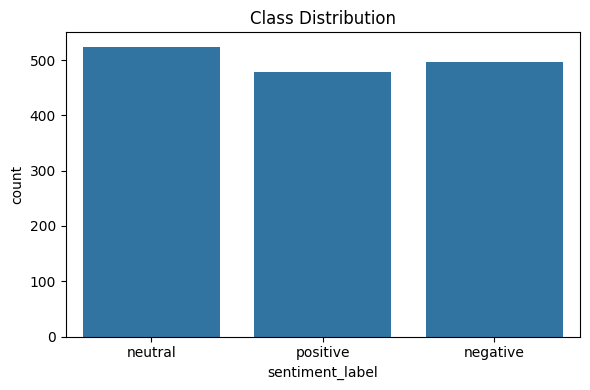

In [195]:
# Class distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='sentiment_label')
plt.title('Class Distribution')
plt.tight_layout()
plt.show()

# Task 2: Text Preprocessing

In [196]:
# Text Cleaning Function
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


df['clean_text'] = df['customer_message'].apply(clean_text)

df[['customer_message', 'clean_text']].head()

,customer_message,clean_text
0,I need information about the payment process. ...,i need information about the payment process m...
1,I need information about the payment process.,i need information about the payment process
2,The refund process was fast and convenient. I ...,the refund process was fast and convenient i a...
3,My refund is still pending and this experience...,my refund is still pending and this experience...
4,Please tell me how to update my account details.,please tell me how to update my account details


# Task 3: Text Vectorization

In [197]:
# Train-Test Split
X = df['clean_text']
y = df['sentiment_label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print('Training samples:', len(X_train))
print('Testing samples:', len(X_test))

Training samples: 1200
Testing samples: 300


In [198]:
# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print('TF-IDF Train Shape:', X_train_tfidf.shape)

TF-IDF Train Shape: (1200, 180)


Machine learning models can only process numerical data. Text must therefore be converted into vectors that represent the importance or position of words. TF-IDF represents each document as a weighted numerical vector.

# Task 4: Baseline Model

In [199]:
# Logistic Regression Model
baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train_tfidf, y_train)

y_pred_baseline = baseline_model.predict(X_test_tfidf)

print(classification_report(y_test, y_pred_baseline))

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        99
     neutral       1.00      1.00      1.00       105
    positive       1.00      1.00      1.00        96

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



In [200]:
# Save Baseline Evaluation
accuracy = accuracy_score(y_test, y_pred_baseline)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred_baseline,
    average='weighted'
)

results_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Value': [accuracy, precision, recall, f1]
})

results_df.to_csv('results/model_evaluation.csv', index=False)
results_df

,Metric,Value
0,Accuracy,1.0
1,Precision,1.0
2,Recall,1.0
3,F1-Score,1.0


In [201]:
# Save Sample Predictions
sample_df = pd.DataFrame({
    'Text': X_test.iloc[:10].values,
    'Actual': y_test.iloc[:10].values,
    'Predicted': y_pred_baseline[:10]
})

sample_df.to_csv('results/sample_predictions.txt', sep='\t', index=False)
sample_df

,Text,Actual,Predicted
0,i like the new payment and it is easy to use m...,positive,positive
1,great service and clear communication from the...,positive,positive
2,my refund is still pending and this experience...,negative,negative
3,the app crashes whenever i try to use analytics,negative,negative
4,the response from the team was helpful and pro...,positive,positive
5,can someone explain the difference between the...,neutral,neutral
6,i like the new video call and it is easy to use,positive,positive
7,i like the new report download and it is easy ...,positive,positive
8,can someone explain the difference between the...,neutral,neutral
9,i want to understand the warranty terms for th...,neutral,neutral


# Task 5: Sequence Model or Conceptual Architecture

In [202]:
# Sequence Model (LSTM)
# Label Encoding

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(df['sentiment_label'])

X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    df['clean_text'],
    y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)

In [203]:
# Tokenization and Padding
MAX_WORDS = 10000
MAX_LEN = 100

# Create tokenizer
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')

# Fit tokenizer on training text
tokenizer.fit_on_texts(X_train_seq)

# Convert text to integer sequences
X_train_sequences = tokenizer.texts_to_sequences(X_train_seq)
X_test_sequences = tokenizer.texts_to_sequences(X_test_seq)

# Pad/truncate sequences to fixed length
X_train_padded = pad_sequences(
    X_train_sequences,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

X_test_padded = pad_sequences(
    X_test_sequences,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

print('Training padded shape:', X_train_padded.shape)
print('Testing padded shape:', X_test_padded.shape)
print('Maximum sequence length:', MAX_LEN)
print('Vocabulary size:', MAX_WORDS)

Training padded shape: (1200, 100)
Testing padded shape: (300, 100)
Maximum sequence length: 100
Vocabulary size: 10000


In [204]:
# Build LSTM Model
num_classes = len(label_encoder.classes_)

lstm_model = Sequential([
    Embedding(MAX_WORDS, 128, input_length=MAX_LEN),
    LSTM(64),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])

lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
lstm_model.build(input_shape=(None, MAX_LEN))

lstm_model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_10 (Embedding)        │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,331,587 (5.08 MB)

 Trainable params: 1,331,587 (5.08 MB)

 Non-trainable params: 0 (0.00 B)

In [205]:
# Train LSTM Model
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = lstm_model.fit(
    X_train_padded,
    y_train_seq,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 180ms/step - accuracy: 0.3510 - loss: 1.1000 - val_accuracy: 0.3042 - val_loss: 1.1010
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 64ms/step - accuracy: 0.3417 - loss: 1.1011 - val_accuracy: 0.3042 - val_loss: 1.1017
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.3354 - loss: 1.0990 - val_accuracy: 0.3375 - val_loss: 1.1000
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step - accuracy: 0.3552 - loss: 1.0992 - val_accuracy: 0.3042 - val_loss: 1.1008
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.3240 - loss: 1.1006 - val_accuracy: 0.3042 - val_loss: 1.1004
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - accuracy: 0.3323 - loss: 1.1006 - val_accuracy: 0.3042 - val_loss: 1.1022


In [206]:
# Evaluate LSTM Model
test_loss, test_accuracy = lstm_model.evaluate(
    X_test_padded,
    y_test_seq,
    verbose=0
)

print(f'LSTM Test Accuracy: {test_accuracy:.4f}')

LSTM Test Accuracy: 0.3500


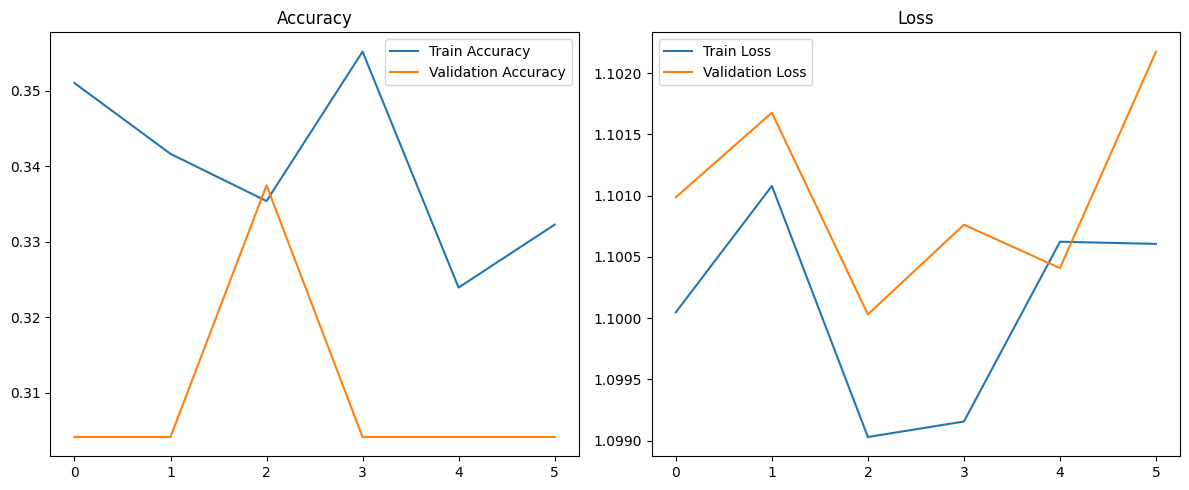

In [207]:
# Plot Training Curves
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Task 6: Attention and Transformer Reflection

## **Why RNNs struggle with long-term dependencies**
RNNs process sequences one step at a time. As sequences become longer, important information from earlier words may be forgotten due to vanishing gradients.

## **How LSTMs help with memory**
LSTMs use gates (input, forget, and output gates) to decide what information to keep or discard, allowing them to capture longer-term dependencies.

- **Input gate** - decides what new information to store.
- **Forget gate** - decides what information to remove.
- **Output gate** - decides what information to pass to the next step.

These gates allow LSTMs to retain important information for longer periods and ignore irrelevant details.

## **What attention solves in sequence-to-sequence tasks**
In sequence-to-sequence tasks such as translation, relying on a single fixed-size context vector can cause information loss, especially for long sentences.

Attention solves this by allowing the model to look at all input words and focus on the most relevant ones when generating each output word. This improves performance and makes the model better at handling long sequences.

## **Why transformers are important in modern NLP and Generative AI**

Transformers are built entirely around self-attention mechanisms and do not rely on recurrence. This enables them to process all words in parallel, making training much faster and more scalable.

Transformers are highly effective at capturing long-range dependencies and understanding context.